# Pipeline

Se incluye:

1. **Clasificación** para predecir `compatible`
2. **Regresión** para predecir `relationship_longevity_months`

## 0. Imports y configuración

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================
# 0. IMPORTS Y CONFIGURACIÓN
# =========================

# Manejo de datos
import pandas as pd
import numpy as np

# Modelado y validación
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

# Preprocesado y pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.inspection import permutation_importance

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Visualización opcional
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


## 1. Carga de datos

In [3]:
# =========================
# 1. CARGA DE DATOS
# =========================

df = pd.read_csv("/content/drive/MyDrive/Máster/Disia/Practica/cupid_algorithm_dataset.csv")

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (100000, 30)


,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


## 2. Inspección inicial

In [4]:
# =========================
# 2. INSPECCIÓN INICIAL
# =========================

# Información general del dataset
df.info()

# Valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Resumen estadístico de variables numéricas
print("\nResumen estadístico:")
display(df.describe())

# Distribución de la variable objetivo de clasificación
print("\nDistribución de 'compatible':")
print(df["compatible"].value_counts())
print(df["compatible"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_love_language                

,pair_id,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,...,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,36.558140,2.951980,0.496463,0.499959,0.500131,0.501397,0.498643,0.499697,0.500012,...,0.499897,0.499177,0.500100,0.500063,0.500779,0.500324,0.500310,63.122273,0.428810,68.906250
std,28867.657797,10.951788,1.117733,0.174898,0.223607,0.224783,0.223860,0.223444,0.224779,0.226265,...,0.223567,0.223989,0.223253,0.223312,0.224214,0.226398,0.225954,10.705780,0.494909,21.334574
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.500000,0.000000,0.000000
25%,25000.750000,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.320000,0.330000,0.330000,...,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,55.900000,0.000000,54.000000
50%,50000.500000,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,63.000000,0.000000,69.000000
75%,75000.250000,46.000000,4.000000,0.620000,0.670000,0.670000,0.680000,0.670000,0.670000,0.670000,...,0.670000,0.670000,0.670000,0.670000,0.680000,0.680000,0.670000,70.300000,1.000000,83.000000
max,100000.000000,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,120.000000



Distribución de 'compatible':
compatible
0    57119
1    42881
Name: count, dtype: int64
compatible
0    0.57119
1    0.42881
Name: proportion, dtype: float64


## 2.1 Feature engineering orientado a la relación entre perfiles

A partir del análisis exploratorio del Hito 2, se construyen variables derivadas que representan **similitud, distancia y coincidencia** entre ambos perfiles. Esto permite que los modelos trabajen sobre la relación entre Persona A y Persona B, en lugar de tratar ambas descripciones como bloques independientes.

In [5]:
# =========================
# 2.1 FEATURE ENGINEERING
# Basado en relaciones entre Persona A y Persona B
# =========================

df_fe = df.copy()

# -------------------------
# Variables relacionales numéricas
# -------------------------
df_fe["age_gap"] = np.abs(df_fe["a_age"] - df_fe["b_age"])
df_fe["education_diff"] = np.abs(df_fe["a_education"] - df_fe["b_education"])
df_fe["ambition_diff"] = np.abs(df_fe["a_career_ambition"] - df_fe["b_career_ambition"])
df_fe["spontaneity_diff"] = np.abs(df_fe["a_spontaneity"] - df_fe["b_spontaneity"])
df_fe["emotional_expressiveness_diff"] = np.abs(
    df_fe["a_emotional_expressiveness"] - df_fe["b_emotional_expressiveness"]
)

personality_traits = ["openness", "extraversion", "agreeableness", "conscientiousness"]
for trait in personality_traits:
    df_fe[f"{trait}_diff"] = np.abs(df_fe[f"a_{trait}"] - df_fe[f"b_{trait}"])

df_fe["personality_distance_mean"] = df_fe[[f"{t}_diff" for t in personality_traits]].mean(axis=1)
df_fe["personality_distance_sum"] = df_fe[[f"{t}_diff" for t in personality_traits]].sum(axis=1)

# -------------------------
# Variables de coincidencia
# -------------------------
df_fe["same_location"] = (df_fe["a_location"] == df_fe["b_location"]).astype(int)
df_fe["same_career_field"] = (df_fe["a_career_field"] == df_fe["b_career_field"]).astype(int)
df_fe["same_chronotype"] = (df_fe["a_chronotype"] == df_fe["b_chronotype"]).astype(int)
df_fe["same_love_language"] = (df_fe["a_love_language"] == df_fe["b_love_language"]).astype(int)

# -------------------------
# Variables por rangos / umbrales
# -------------------------
df_fe["age_gap_small"] = (df_fe["age_gap"] <= 5).astype(int)
df_fe["age_gap_medium"] = ((df_fe["age_gap"] > 5) & (df_fe["age_gap"] <= 10)).astype(int)
df_fe["age_gap_large"] = (df_fe["age_gap"] > 10).astype(int)
df_fe["very_large_age_gap"] = (df_fe["age_gap"] > 15).astype(int)

df_fe["high_personality_similarity"] = (df_fe["personality_distance_mean"] < 0.20).astype(int)
df_fe["similar_ambition"] = (df_fe["ambition_diff"] < 0.20).astype(int)

# -------------------------
# Interacciones / score agregado
# -------------------------
df_fe["same_location_and_love_language"] = (
    df_fe["same_location"] * df_fe["same_love_language"]
)

df_fe["overall_match_score"] = (
    (1 - df_fe["personality_distance_mean"]) * 0.45 +
    (1 - df_fe["ambition_diff"]) * 0.25 +
    df_fe["same_location"] * 0.10 +
    df_fe["same_love_language"] * 0.10 +
    (1 - np.clip(df_fe["age_gap"] / 20, 0, 1)) * 0.10
)

# -------------------------
# Conjunto final de features modelables
# -------------------------
engineered_feature_cols = [
    "age_gap", "education_diff", "ambition_diff", "spontaneity_diff",
    "emotional_expressiveness_diff",
    "openness_diff", "extraversion_diff", "agreeableness_diff", "conscientiousness_diff",
    "personality_distance_mean", "personality_distance_sum",
    "same_location", "same_career_field", "same_chronotype", "same_love_language",
    "age_gap_small", "age_gap_medium", "age_gap_large", "very_large_age_gap",
    "high_personality_similarity", "similar_ambition",
    "same_location_and_love_language", "overall_match_score"
]

print(f"Número de variables de feature engineering: {len(engineered_feature_cols)}")
display(df_fe[engineered_feature_cols + ['compatible', 'relationship_longevity_months']].head())

Número de variables de feature engineering: 23


,age_gap,education_diff,ambition_diff,spontaneity_diff,emotional_expressiveness_diff,openness_diff,extraversion_diff,agreeableness_diff,conscientiousness_diff,personality_distance_mean,...,age_gap_small,age_gap_medium,age_gap_large,very_large_age_gap,high_personality_similarity,similar_ambition,same_location_and_love_language,overall_match_score,compatible,relationship_longevity_months
0,26,0,0.54,0.19,0.14,0.32,0.17,0.35,0.01,0.2125,...,0,0,1,1,0,0,0,0.469375,0,60
1,6,1,0.14,0.16,0.11,0.07,0.39,0.31,0.14,0.2275,...,0,1,0,0,0,1,0,0.632625,0,59
2,21,2,0.02,0.17,0.21,0.05,0.57,0.15,0.39,0.2900,...,0,0,1,1,0,1,0,0.664500,1,84
3,18,2,0.15,0.25,0.06,0.13,0.07,0.26,0.60,0.2650,...,0,0,1,1,0,1,0,0.553250,0,70
4,14,1,0.07,0.27,0.06,0.09,0.04,0.18,0.30,0.1525,...,0,0,1,0,1,1,0,0.743875,1,68


## 3. Bloque 1 — Clasificación de `compatible`

En este bloque:
- separamos `X` e `y`,
- hacemos train/validation/test split estratificado,
- seleccionamos variables con `mutual_info_classif`,
- ajustamos una **Logistic Regression** con GridSearch,
- y la comparamos contra **Random Forest**.


In [6]:

# =========================
# 3. CLASIFICACIÓN: PREDECIR 'compatible'
# Split 70% train / 15% validation / 15% test
# =========================

# Variables predictoras y target
X_clf = df_fe[engineered_feature_cols].copy()
y_clf = df_fe["compatible"]

# One-hot encoding sobre variables categóricas derivadas
X_clf = pd.get_dummies(X_clf, drop_first=True)

# 70% train / 30% temporal
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# 15% validation / 15% test
X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf,
    y_temp_clf,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp_clf
)

print("Shapes clasificación:")
print("Train:", X_train_clf.shape, y_train_clf.shape)
print("Validation:", X_val_clf.shape, y_val_clf.shape)
print("Test:", X_test_clf.shape, y_test_clf.shape)
print("\nDistribución train:")
print(y_train_clf.value_counts(normalize=True))


Shapes clasificación:
Train: (70000, 23) (70000,)
Validation: (15000, 23) (15000,)
Test: (15000, 23) (15000,)

Distribución train:
compatible
0    0.571186
1    0.428814
Name: proportion, dtype: float64


In [7]:
# =========================
# 3.1 FEATURE SELECTION PARA CLASIFICACIÓN
# (solo usando train para evitar leakage)
# =========================

mi_clf = mutual_info_classif(
    X_train_clf,
    y_train_clf,
    random_state=RANDOM_STATE
)

mi_clf_series = pd.Series(mi_clf, index=X_train_clf.columns).sort_values(ascending=False)

print("Top 15 features por mutual information:")
display(mi_clf_series.head(15))

threshold_clf = 0.001
selected_features_clf = mi_clf_series[mi_clf_series > threshold_clf].index.tolist()

if len(selected_features_clf) == 0:
    selected_features_clf = mi_clf_series.head(20).index.tolist()

print(f"Número de features seleccionadas para clasificación: {len(selected_features_clf)}")
print(selected_features_clf)

X_train_clf_sel = X_train_clf[selected_features_clf]
X_val_clf_sel = X_val_clf[selected_features_clf]
X_test_clf_sel = X_test_clf[selected_features_clf]


Top 15 features por mutual information:


,0
overall_match_score,0.064956
same_love_language,0.050687
ambition_diff,0.026906
similar_ambition,0.025704
emotional_expressiveness_diff,0.024648
same_location_and_love_language,0.019650
personality_distance_sum,0.017656
personality_distance_mean,0.014726
high_personality_similarity,0.010161
spontaneity_diff,0.009406


Número de features seleccionadas para clasificación: 20
['overall_match_score', 'same_love_language', 'ambition_diff', 'similar_ambition', 'emotional_expressiveness_diff', 'same_location_and_love_language', 'personality_distance_sum', 'personality_distance_mean', 'high_personality_similarity', 'spontaneity_diff', 'age_gap_large', 'very_large_age_gap', 'same_career_field', 'same_location', 'age_gap_small', 'age_gap', 'education_diff', 'extraversion_diff', 'agreeableness_diff', 'openness_diff']


### Justificación de la selección de modelos

Con el objetivo de abordar el problema de predicción de compatibilidad y longevidad relacional, se han seleccionado modelos pertenecientes a distintas familias de aprendizaje automático, permitiendo comparar enfoques diversos sobre un mismo conjunto de datos.

- Modelos lineales (Logistic Regression en clasificación y Ridge en regresión), que proporcionan una línea base interpretable. Tras el proceso de ingeniería de características realizado, donde se han construido variables de similitud y diferencia entre individuos (por ejemplo, diferencias de personalidad, coincidencias en lenguaje del amor o localización), resulta razonable evaluar si estas relaciones pueden modelarse mediante combinaciones lineales.

- Árboles de decisión (Decision Tree y Decision Tree Regressor), que permiten capturar relaciones no lineales y reglas basadas en umbrales. En el contexto de este problema, es plausible que existan reglas del tipo “si la diferencia de edad es alta y no coinciden en ciertas variables clave, la compatibilidad disminuye”, lo que justifica el uso de este tipo de modelos.

- Métodos ensemble como Random Forest y Gradient Boosting, junto con sus variantes de regresión, ya que suelen ofrecer un alto rendimiento en datos tabulares estructurados. Estos modelos son especialmente adecuados para capturar interacciones complejas entre variables derivadas del perfil de ambos individuos, algo esperable en un problema multidimensional como el de la compatibilidad relacional.

- Modelos basados en distancia como KNN y KNN Regressor. Este enfoque resulta especialmente relevante en este contexto, dado que el problema se ha formulado en términos de similitud entre perfiles. Así, KNN permite evaluar si parejas con características similares a otras previamente observadas presentan también comportamientos similares en términos de compatibilidad o longevidad.

Finalmente, para la tarea de regresión se han seleccionado las variantes equivalentes de los modelos utilizados en clasificación, con el fin de mantener coherencia metodológica y facilitar la comparación entre ambos problemas.

En conjunto, esta selección permite analizar el comportamiento de modelos lineales, modelos basados en reglas, métodos ensemble y algoritmos basados en distancia en un problema complejo y multifactorial como el estudiado.


### Justificación de la selección de modelos (clasificación)

Para abordar el problema de predicción de compatibilidad, se han seleccionado modelos pertenecientes a distintas familias de aprendizaje automático con el objetivo de comparar enfoques diversos sobre un mismo conjunto de datos.

- Modelo lineal base, se incluye Logistic Regression, que permite evaluar si las variables derivadas generadas durante el proceso de ingeniería de características (como similitudes y diferencias entre individuos) pueden explicar la compatibilidad mediante relaciones aproximadamente lineales.

- Modelos basados en árboles de decisión (Decision Tree), que permiten capturar relaciones no lineales y reglas basadas en umbrales. Este tipo de enfoque resulta adecuado en este contexto, donde pueden existir combinaciones específicas de características que influyan en la compatibilidad.

- Métodos ensemble como Random Forest y Gradient Boosting, que combinan múltiples modelos para mejorar el rendimiento y capturar interacciones complejas entre variables, algo esperable en un problema multidimensional como el de la compatibilidad relacional.

- Modelo basado en distancia, se incluye KNN, especialmente relevante en este caso, ya que el problema se ha formulado en términos de similitud entre perfiles. Este modelo permite evaluar si la proximidad entre parejas en el espacio de características es suficiente para predecir la compatibilidad.

En conjunto, esta selección permite analizar el comportamiento de modelos lineales, modelos basados en reglas, métodos ensemble y algoritmos basados en distancia en la tarea de clasificación.

In [8]:

# =========================
# 3.2 DEFINICIÓN DE LOS 5 MODELOS DE CLASIFICACIÓN
# =========================

classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            C=1.0,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE
        ))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=25, weights="distance"))
    ])
}

def evaluate_classification(model, X, y_true, dataset_name, model_name):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y_true, y_prob)
    else:
        roc_auc = np.nan

    return {
        "Modelo": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc
    }


### Justificación de los hiperparámetros (clasificación)

Los hiperparámetros de los modelos de clasificación se han fijado utilizando valores comúnmente aceptados como configuraciones razonables en la práctica habitual y en ejemplos de referencia de la literatura y la documentación de las librerías utilizadas.

En el caso de los modelos basados en árboles, se han limitado parámetros como la profundidad máxima o el número de estimadores con el fin de evitar sobreajuste y mantener un compromiso entre capacidad predictiva e interpretabilidad. En modelos como KNN, se ha utilizado un número reducido de vecinos para preservar la sensibilidad a patrones locales en el espacio de características. En el caso de Logistic Regression, se ha mantenido una configuración estándar adecuada para un problema binario con variables ya transformadas mediante ingeniería de características.

Dado el alcance del hito y las restricciones temporales del trabajo, no se ha realizado una optimización exhaustiva de hiperparámetros mediante técnicas como Grid Search o Random Search. El objetivo principal en esta fase es comparar el comportamiento relativo de distintas familias de modelos bajo configuraciones razonables, más que maximizar de forma específica el rendimiento de cada uno de ellos.

Como posible mejora futura, sería recomendable realizar un ajuste sistemático de hiperparámetros para analizar hasta qué punto puede mejorarse el rendimiento, especialmente en aquellos modelos más sensibles a esta configuración, como Decision Tree, Random Forest, Gradient Boosting y KNN.

In [9]:
# =========================
# 3.3 ENTRENAMIENTO Y EVALUACIÓN EN VALIDATION
# =========================

classification_results = []
trained_classification_models = {}

for model_name, model in classification_models.items():
    model.fit(X_train_clf_sel, y_train_clf)
    trained_classification_models[model_name] = model

    val_metrics = evaluate_classification(
        model,
        X_val_clf_sel,
        y_val_clf,
        dataset_name="Validation",
        model_name=model_name
    )
    classification_results.append(val_metrics)

results_clf_val = pd.DataFrame(classification_results).sort_values(
    by=["F1", "ROC-AUC"], ascending=False
).reset_index(drop=True)

print("===== RESULTADOS EN VALIDATION (Clasificación) =====")
display(results_clf_val)


===== RESULTADOS EN VALIDATION (Clasificación) =====


,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Validation,0.705333,0.644044,0.699316,0.670543,0.783819
1,Random Forest,Validation,0.710667,0.657530,0.678794,0.667993,0.780666
2,Decision Tree,Validation,0.690200,0.625404,0.692009,0.657023,0.761423
3,Gradient Boosting,Validation,0.715067,0.689831,0.609608,0.647243,0.784109
4,KNN,Validation,0.701533,0.666157,0.609297,0.636460,0.759690


Mejor modelo de clasificación según Validation: Logistic Regression

===== RESULTADO DEL MEJOR MODELO EN VALIDATION =====


,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Validation,0.705333,0.644044,0.699316,0.670543,0.783819



Classification report (Validation):
              precision    recall  f1-score   support

           0       0.76      0.71      0.73      8568
           1       0.64      0.70      0.67      6432

    accuracy                           0.71     15000
   macro avg       0.70      0.70      0.70     15000
weighted avg       0.71      0.71      0.71     15000



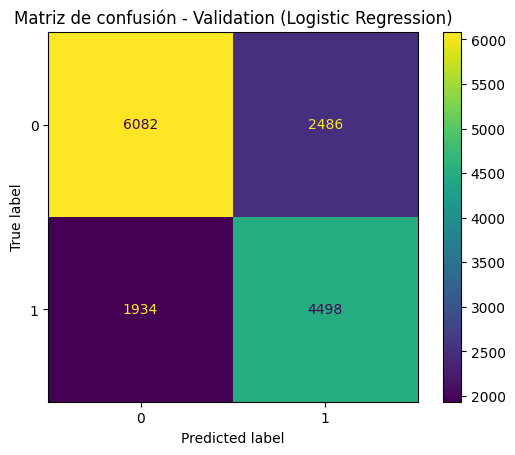


===== RESULTADO FINAL EN TEST (Clasificación) =====


,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Test,0.7182,0.659945,0.707245,0.682777,0.791749



Classification report (Test):
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      8568
           1       0.66      0.71      0.68      6432

    accuracy                           0.72     15000
   macro avg       0.71      0.72      0.71     15000
weighted avg       0.72      0.72      0.72     15000



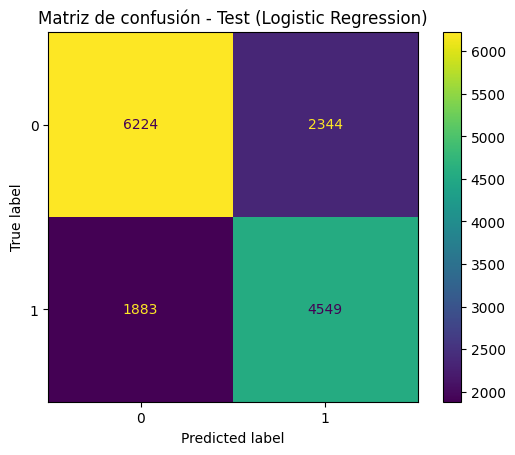

In [10]:
# =========================
# 3.4 SELECCIÓN DEL MEJOR MODELO Y EVALUACIÓN FINAL EN TEST
# =========================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_clf_name = results_clf_val.iloc[0]["Modelo"]
best_clf_model = trained_classification_models[best_clf_name]

print(f"Mejor modelo de clasificación según Validation: {best_clf_name}")

# -------------------------
# Evaluación en VALIDATION
# -------------------------
val_metrics_best_clf = evaluate_classification(
    best_clf_model,
    X_val_clf_sel,
    y_val_clf,
    dataset_name="Validation",
    model_name=best_clf_name
)

results_clf_best_val = pd.DataFrame([val_metrics_best_clf])

print("\n===== RESULTADO DEL MEJOR MODELO EN VALIDATION =====")
display(results_clf_best_val)

y_pred_best_clf_val = best_clf_model.predict(X_val_clf_sel)

print("\nClassification report (Validation):")
print(classification_report(y_val_clf, y_pred_best_clf_val))

cm_val = confusion_matrix(y_val_clf, y_pred_best_clf_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp_val.plot()
plt.title(f"Matriz de confusión - Validation ({best_clf_name})")
plt.show()

# -------------------------
# Evaluación en TEST
# -------------------------
test_metrics_best_clf = evaluate_classification(
    best_clf_model,
    X_test_clf_sel,
    y_test_clf,
    dataset_name="Test",
    model_name=best_clf_name
)

results_clf_test = pd.DataFrame([test_metrics_best_clf])

print("\n===== RESULTADO FINAL EN TEST (Clasificación) =====")
display(results_clf_test)

y_pred_best_clf = best_clf_model.predict(X_test_clf_sel)

print("\nClassification report (Test):")
print(classification_report(y_test_clf, y_pred_best_clf))

cm_test = confusion_matrix(y_test_clf, y_pred_best_clf)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot()
plt.title(f"Matriz de confusión - Test ({best_clf_name})")
plt.show()

Las matrices de confusión obtenidas en los conjuntos de validación y test muestran un comportamiento consistente del modelo, lo que indica una buena capacidad de generalización.

Se observa que el modelo es capaz de clasificar correctamente un número elevado de instancias en ambas clases, manteniendo un equilibrio razonable entre verdaderos positivos y verdaderos negativos.

No obstante, se aprecia una mayor presencia de falsos positivos frente a falsos negativos, lo que sugiere que el modelo tiende a predecir la compatibilidad en mayor medida de lo debido. Este comportamiento puede interpretarse como una cierta inclinación del modelo hacia decisiones más permisivas en términos de compatibilidad.

En conjunto, los resultados reflejan un rendimiento sólido y coherente con las métricas obtenidas previamente, validando la elección del modelo de regresión logística como solución adecuada para este problema.

In [11]:
# =========================
# 3.5 EVALUACIÓN DE TODOS LOS MODELOS EN TEST
# =========================

classification_test_results = []

for model_name, model in trained_classification_models.items():
    test_metrics = evaluate_classification(
        model,
        X_test_clf_sel,
        y_test_clf,
        dataset_name="Test",
        model_name=model_name
    )
    classification_test_results.append(test_metrics)

results_clf_test_all = pd.DataFrame(classification_test_results).sort_values(
    by=["F1", "ROC-AUC"], ascending=False
).reset_index(drop=True)

print("===== RESULTADOS DE TODOS LOS MODELOS EN TEST (Clasificación) =====")
display(results_clf_test_all)

===== RESULTADOS DE TODOS LOS MODELOS EN TEST (Clasificación) =====


,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Test,0.718200,0.659945,0.707245,0.682777,0.791749
1,Random Forest,Test,0.719933,0.668938,0.686723,0.677714,0.790521
2,Decision Tree,Test,0.695333,0.630575,0.699005,0.663029,0.767879
3,Gradient Boosting,Test,0.724733,0.705662,0.614272,0.656803,0.792267
4,KNN,Test,0.705067,0.671097,0.612251,0.640325,0.768773


In [13]:
# =========================
# 3.6 COMPARATIVA GLOBAL CLASIFICACIÓN (Validation + Test)
# =========================

results_clf_all = pd.concat(
    [results_clf_val, results_clf_test_all],
    ignore_index=True
)

display(
    results_clf_all.sort_values(
        by=["Dataset", "F1"],
        ascending=[True, False]
    )
)

,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
5,Logistic Regression,Test,0.718200,0.659945,0.707245,0.682777,0.791749
6,Random Forest,Test,0.719933,0.668938,0.686723,0.677714,0.790521
7,Decision Tree,Test,0.695333,0.630575,0.699005,0.663029,0.767879
8,Gradient Boosting,Test,0.724733,0.705662,0.614272,0.656803,0.792267
9,KNN,Test,0.705067,0.671097,0.612251,0.640325,0.768773
0,Logistic Regression,Validation,0.705333,0.644044,0.699316,0.670543,0.783819
1,Random Forest,Validation,0.710667,0.657530,0.678794,0.667993,0.780666
2,Decision Tree,Validation,0.690200,0.625404,0.692009,0.657023,0.761423
3,Gradient Boosting,Validation,0.715067,0.689831,0.609608,0.647243,0.784109
4,KNN,Validation,0.701533,0.666157,0.609297,0.636460,0.759690


In [15]:
# =========================
# 3.7 INTERPRETABILIDAD DEL MEJOR MODELO DE CLASIFICACIÓN
# =========================

if best_clf_name == "Logistic Regression":
    coef_clf = pd.DataFrame({
        "feature": selected_features_clf,
        "coef": best_clf_model.named_steps["model"].coef_[0]
    }).sort_values(by="coef", key=abs, ascending=False)

    print("Top 15 coeficientes absolutos de Logistic Regression:")
    display(coef_clf.head(15))

elif best_clf_name in ["Random Forest", "Gradient Boosting", "Decision Tree"]:
    importance_clf = pd.DataFrame({
        "feature": selected_features_clf,
        "importance": best_clf_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print(f"Top 15 importancias de {best_clf_name}:")
    display(importance_clf.head(15))

else:
    print(f"El modelo seleccionado ({best_clf_name}) no dispone de importancias o coeficientes directos fácilmente interpretables.")


Top 15 coeficientes absolutos de Logistic Regression:


,feature,coef
1,same_love_language,0.611900
4,emotional_expressiveness_diff,-0.563530
2,ambition_diff,-0.439404
0,overall_match_score,0.426603
9,spontaneity_diff,-0.371039
12,same_career_field,0.205232
19,openness_diff,-0.103336
17,extraversion_diff,-0.088654
13,same_location,-0.087879
7,personality_distance_mean,-0.067114


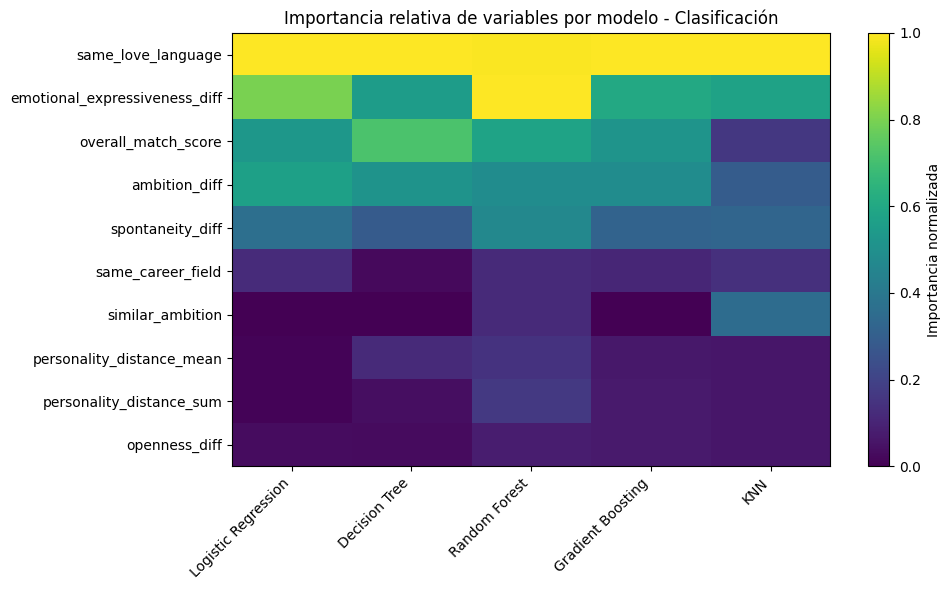

,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting,KNN
same_love_language,0.049357,0.061134,0.038934,0.067062,0.052301
emotional_expressiveness_diff,0.039355,0.033687,0.039220,0.040521,0.030202
overall_match_score,0.026127,0.043782,0.022770,0.034657,0.008495
ambition_diff,0.028014,0.031382,0.019097,0.032712,0.015217
spontaneity_diff,0.018009,0.017459,0.018247,0.021410,0.017016
same_career_field,0.006009,0.001455,0.004724,0.007314,0.007274
similar_ambition,0.000163,0.000000,0.004659,0.000000,0.018459
personality_distance_mean,0.000572,0.007278,0.005703,0.004228,0.003154
personality_distance_sum,0.000572,0.002187,0.006563,0.004751,0.003154
openness_diff,0.001684,0.001712,0.003195,0.004973,0.003143


In [ ]:
# =========================
# 3.8 IMPORTANCIA DE VARIABLES - CLASIFICACIÓN
# =========================

perm_importances_clf = {}

for name, model in classification_models.items():
    result = permutation_importance(
        model,
        X_val_clf_sel,
        y_val_clf,
        n_repeats=10,
        random_state=42,
        scoring="f1"
    )

    importances = pd.Series(result.importances_mean, index=selected_features_clf)
    perm_importances_clf[name] = importances

perm_importances_clf_df = pd.DataFrame(perm_importances_clf).fillna(0)

# Nos quedamos con las 10 variables más relevantes en promedio
top_features_clf = perm_importances_clf_df.mean(axis=1).sort_values(ascending=False).head(10).index
perm_importances_clf_top = perm_importances_clf_df.loc[top_features_clf]

# Normalización por modelo para que sean comparables visualmente
perm_importances_clf_norm = perm_importances_clf_top.copy()
for col in perm_importances_clf_norm.columns:
    max_val = perm_importances_clf_norm[col].abs().max()
    if max_val > 0:
        perm_importances_clf_norm[col] = perm_importances_clf_norm[col] / max_val

# Heatmap simple con matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(perm_importances_clf_norm, aspect="auto")
plt.colorbar(label="Importancia normalizada")
plt.xticks(ticks=np.arange(len(perm_importances_clf_norm.columns)), labels=perm_importances_clf_norm.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(perm_importances_clf_norm.index)), labels=perm_importances_clf_norm.index)
plt.title("Importancia relativa de variables por modelo - Clasificación")
plt.tight_layout()
plt.show()

display(perm_importances_clf_top)

## 4. Bloque 2 — Regresión de `relationship_longevity_months`

En este bloque:
- cambiamos el target a la duración de la relación,
- evitamos leakage eliminando `compatible` y `compatibility_score`,
- usamos una partición **70/15/15**,
- entrenamos **5 modelos distintos de regresión**,
- y comparamos su rendimiento con MAE, RMSE y $R^2$.


In [16]:

# =========================
# 4. REGRESIÓN: PREDECIR 'relationship_longevity_months'
# Split 70% train / 15% validation / 15% test
# =========================

X_reg = df_fe[engineered_feature_cols].copy()
y_reg = df_fe["relationship_longevity_months"]

X_reg = pd.get_dummies(X_reg, drop_first=True)

# Transformación logarítmica para estabilizar la distribución
y_reg_log = np.log1p(y_reg)

# 70% train / 30% temporal
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg,
    y_reg_log,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# 15% validation / 15% test
X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg,
    y_temp_reg,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Shapes regresión:")
print("Train:", X_train_reg.shape, y_train_reg.shape)
print("Validation:", X_val_reg.shape, y_val_reg.shape)
print("Test:", X_test_reg.shape, y_test_reg.shape)


Shapes regresión:
Train: (70000, 23) (70000,)
Validation: (15000, 23) (15000,)
Test: (15000, 23) (15000,)


In [17]:
# =========================
# 4.1 FEATURE SELECTION PARA REGRESIÓN
# (solo usando train para evitar leakage)
# =========================

mi_reg = mutual_info_regression(X_train_reg, y_train_reg, random_state=RANDOM_STATE)

mi_reg_series = pd.Series(mi_reg, index=X_train_reg.columns).sort_values(ascending=False)

print("Top 15 features por mutual information (regresión):")
display(mi_reg_series.head(15))

threshold_reg = 0.001
selected_features_reg = mi_reg_series[mi_reg_series > threshold_reg].index.tolist()

if len(selected_features_reg) == 0:
    selected_features_reg = mi_reg_series.head(20).index.tolist()

print(f"Número de features seleccionadas para regresión: {len(selected_features_reg)}")

X_train_reg_sel = X_train_reg[selected_features_reg]
X_val_reg_sel = X_val_reg[selected_features_reg]
X_test_reg_sel = X_test_reg[selected_features_reg]


Top 15 features por mutual information (regresión):


,0
overall_match_score,0.025674
same_love_language,0.024178
personality_distance_mean,0.011794
personality_distance_sum,0.011032
ambition_diff,0.010671
emotional_expressiveness_diff,0.008853
same_location_and_love_language,0.008723
similar_ambition,0.008610
openness_diff,0.006896
spontaneity_diff,0.005741


Número de features seleccionadas para regresión: 16


### Justificación de la selección de modelos (regresión)

Para la tarea de predicción de la longevidad relacional, se han seleccionado las variantes de regresión de los modelos utilizados previamente en clasificación, con el objetivo de mantener coherencia metodológica y facilitar la comparación entre ambos problemas.

En este sentido, se emplean modelos lineales (Ridge), árboles de decisión (Decision Tree Regressor), métodos ensemble (Random Forest Regressor y Gradient Boosting Regressor) y modelos basados en distancia (KNN Regressor).

Esta elección permite analizar cómo se comportan las mismas familias de modelos en un problema de regresión, que presenta una mayor complejidad, al tratar de predecir una variable continua como es la duración de la relación, frente al problema binario de compatibilidad.

In [18]:

# =========================
# 4.2 DEFINICIÓN DE LOS 5 MODELOS DE REGRESIÓN
# =========================

regression_models = {
    "Ridge": Ridge(alpha=1.0),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

def evaluate_regression(model, X, y_true_log, dataset_name, model_name):
    y_pred_log = model.predict(X)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_true_log)

    return {
        "Modelo": model_name,
        "Dataset": dataset_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


### Justificación de los hiperparámetros (regresión)

En la tarea de regresión se han utilizado configuraciones de hiperparámetros análogas a las empleadas en clasificación, adaptadas a sus correspondientes variantes de regresión. Esta decisión permite mantener coherencia metodológica entre ambos problemas y facilita la comparación del comportamiento de las distintas familias de modelos.

En particular, se han seleccionado valores conservadores que evitan configuraciones excesivamente complejas, dado que el objetivo de esta fase no es llevar a cabo una optimización fina del rendimiento, sino comparar enfoques lineales, basados en árboles, ensemble y basados en distancia sobre la predicción de longevidad relacional.

Al igual que en clasificación, no se ha realizado un proceso exhaustivo de optimización de hiperparámetros. Esta decisión se justifica por el carácter comparativo del hito y por la necesidad de mantener una evaluación homogénea entre modelos. Como trabajo futuro, sería interesante analizar el impacto de una optimización específica, especialmente en modelos como Random Forest Regressor, Gradient Boosting Regressor o KNN Regressor.

In [19]:
# =========================
# 4.3 ENTRENAMIENTO Y EVALUACIÓN EN VALIDATION
# =========================

regression_results = []
trained_regression_models = {}

for model_name, model in regression_models.items():
    model.fit(X_train_reg_sel, y_train_reg)
    trained_regression_models[model_name] = model

    val_metrics = evaluate_regression(
        model,
        X_val_reg_sel,
        y_val_reg,
        dataset_name="Validation",
        model_name=model_name
    )
    regression_results.append(val_metrics)

results_reg_val = pd.DataFrame(regression_results).sort_values(
    by=["MAE", "RMSE"], ascending=True
).reset_index(drop=True)

print("===== RESULTADOS EN VALIDATION (Regresión) =====")
display(results_reg_val)


===== RESULTADOS EN VALIDATION (Regresión) =====


,Modelo,Dataset,MAE,RMSE,R2
0,Ridge,Validation,16.438185,20.482438,0.080404
1,Gradient Boosting,Validation,16.448593,20.495582,0.079223
2,Random Forest,Validation,16.510136,20.574771,0.072095
3,Decision Tree,Validation,16.928690,21.134641,0.020908
4,KNN,Validation,18.098933,22.627234,-0.122268


In [20]:
# =========================
# 4.4 SELECCIÓN DEL MEJOR MODELO Y EVALUACIÓN FINAL EN TEST
# =========================

best_reg_name = results_reg_val.iloc[0]["Modelo"]
best_reg_model = trained_regression_models[best_reg_name]

print(f"Mejor modelo de regresión según Validation: {best_reg_name}")

test_metrics_best_reg = evaluate_regression(
    best_reg_model,
    X_test_reg_sel,
    y_test_reg,
    dataset_name="Test",
    model_name=best_reg_name
)

results_reg_test = pd.DataFrame([test_metrics_best_reg])

print("\n===== RESULTADO FINAL EN TEST (Regresión) =====")
display(results_reg_test)


Mejor modelo de regresión según Validation: Ridge

===== RESULTADO FINAL EN TEST (Regresión) =====


,Modelo,Dataset,MAE,RMSE,R2
0,Ridge,Test,16.271024,20.333607,0.075771


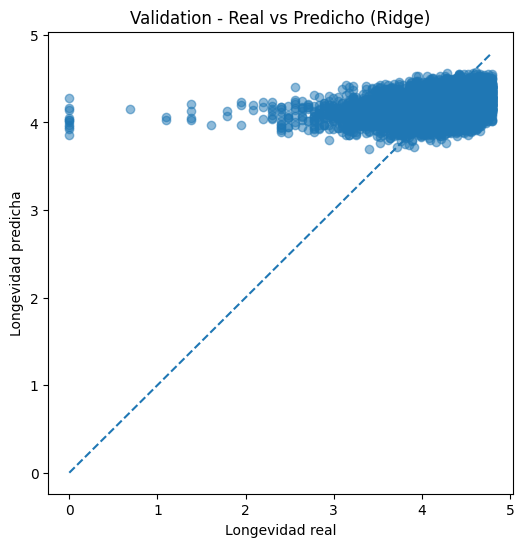

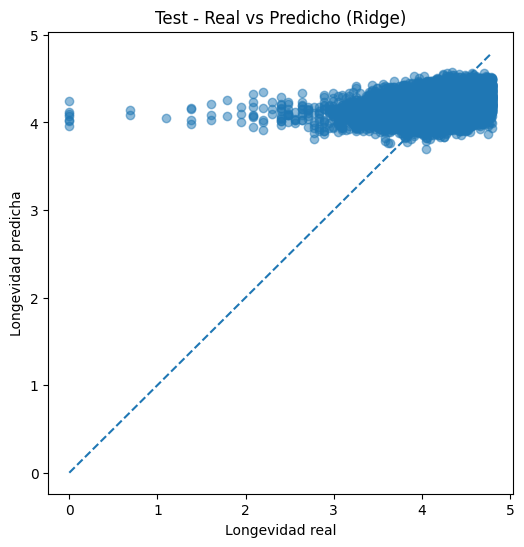

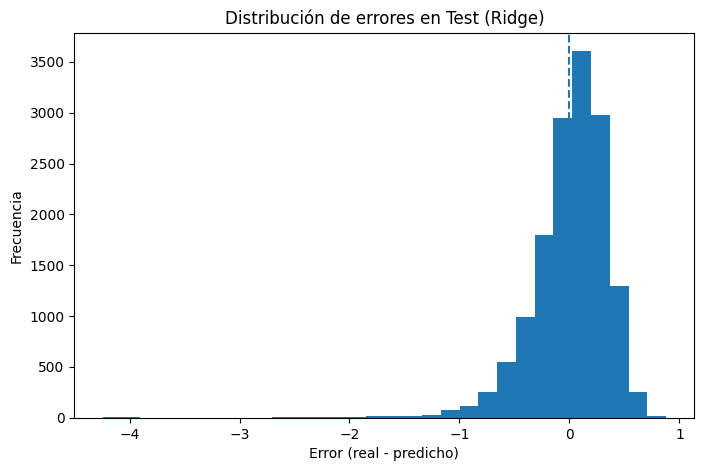

In [21]:
# =========================
# 4.5 ANÁLISIS GRÁFICO DEL MEJOR MODELO DE REGRESIÓN
# =========================

import matplotlib.pyplot as plt
import numpy as np

# Predicciones del mejor modelo en validation y test
y_val_pred_best_reg = best_reg_model.predict(X_val_reg_sel)
y_test_pred_best_reg = best_reg_model.predict(X_test_reg_sel)

# -------------------------
# 1. REAL VS PREDICHO - VALIDATION
# -------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_val_reg, y_val_pred_best_reg, alpha=0.5)
plt.plot(
    [y_val_reg.min(), y_val_reg.max()],
    [y_val_reg.min(), y_val_reg.max()],
    linestyle="--"
)
plt.xlabel("Longevidad real")
plt.ylabel("Longevidad predicha")
plt.title(f"Validation - Real vs Predicho ({best_reg_name})")
plt.show()

# -------------------------
# 2. REAL VS PREDICHO - TEST
# -------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_test_pred_best_reg, alpha=0.5)
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    linestyle="--"
)
plt.xlabel("Longevidad real")
plt.ylabel("Longevidad predicha")
plt.title(f"Test - Real vs Predicho ({best_reg_name})")
plt.show()

# -------------------------
# 3. DISTRIBUCIÓN DE ERRORES - TEST
# -------------------------
errors_test = y_test_reg - y_test_pred_best_reg

plt.figure(figsize=(8, 5))
plt.hist(errors_test, bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.title(f"Distribución de errores en Test ({best_reg_name})")
plt.show()

El análisis gráfico del modelo de regresión revela que las predicciones tienden a concentrarse en torno a un rango reducido de valores, sin seguir adecuadamente la diagonal ideal que representaría una predicción perfecta. Esto indica que el modelo presenta una capacidad limitada para capturar la variabilidad de la variable objetivo.

En particular, se observa un fenómeno de regresión hacia la media, donde el modelo tiende a predecir valores cercanos al promedio independientemente del valor real. Este comportamiento es consistente con el bajo valor de R² obtenido, lo que sugiere que las variables disponibles no explican suficientemente la longevidad relacional.

Asimismo, la distribución de errores muestra una ligera asimetría, indicando que el modelo tiende a sobreestimar en ciertos casos, especialmente cuando la longevidad real es baja.

En conjunto, estos resultados reflejan la mayor complejidad del problema de regresión en comparación con la clasificación de compatibilidad, lo cual es coherente puesto que predecir la duración depende tambien de factores no presentes en el dataset.

In [22]:
# =========================
# 4.6 EVALUACIÓN DE TODOS LOS MODELOS EN TEST
# =========================

regression_test_results = []

for model_name, model in trained_regression_models.items():
    test_metrics = evaluate_regression(
        model,
        X_test_reg_sel,
        y_test_reg,
        dataset_name="Test",
        model_name=model_name
    )
    regression_test_results.append(test_metrics)

results_reg_test_all = pd.DataFrame(regression_test_results).sort_values(
    by=["MAE", "RMSE"], ascending=True
).reset_index(drop=True)

print("===== RESULTADOS DE TODOS LOS MODELOS EN TEST (Regresión) =====")
display(results_reg_test_all)

===== RESULTADOS DE TODOS LOS MODELOS EN TEST (Regresión) =====


,Modelo,Dataset,MAE,RMSE,R2
0,Ridge,Test,16.271024,20.333607,0.075771
1,Gradient Boosting,Test,16.294776,20.341069,0.075093
2,Random Forest,Test,16.346928,20.408670,0.068935
3,Decision Tree,Test,16.823409,21.045553,0.009918
4,KNN,Test,17.993876,22.463184,-0.127959


In [23]:
# =========================
# 4.7 COMPARATIVA GLOBAL REGRESIÓN (Validation + Test)
# =========================

results_reg_all = pd.concat(
    [results_reg_val, results_reg_test_all],
    ignore_index=True
)

display(
    results_reg_all.sort_values(
        by=["Dataset", "MAE"],
        ascending=[True, True]
    )
)


,Modelo,Dataset,MAE,RMSE,R2
5,Ridge,Test,16.271024,20.333607,0.075771
6,Gradient Boosting,Test,16.294776,20.341069,0.075093
7,Random Forest,Test,16.346928,20.408670,0.068935
8,Decision Tree,Test,16.823409,21.045553,0.009918
9,KNN,Test,17.993876,22.463184,-0.127959
0,Ridge,Validation,16.438185,20.482438,0.080404
1,Gradient Boosting,Validation,16.448593,20.495582,0.079223
2,Random Forest,Validation,16.510136,20.574771,0.072095
3,Decision Tree,Validation,16.928690,21.134641,0.020908
4,KNN,Validation,18.098933,22.627234,-0.122268


In [24]:
# =========================
# 4.6 INTERPRETABILIDAD DEL MEJOR MODELO DE REGRESIÓN
# =========================

if best_reg_name in ["Linear Regression", "Ridge"]:
    coef_reg = pd.DataFrame({
        "feature": selected_features_reg,
        "coef": best_reg_model.coef_
    }).sort_values(by="coef", key=abs, ascending=False)

    print(f"Top 15 coeficientes absolutos de {best_reg_name}:")
    display(coef_reg.head(15))

elif best_reg_name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
    importance_reg = pd.DataFrame({
        "feature": selected_features_reg,
        "importance": best_reg_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print(f"Top 15 importancias de {best_reg_name}:")
    display(importance_reg.head(15))

else:
    print(f"El modelo seleccionado ({best_reg_name}) no dispone de importancias o coeficientes directos fácilmente interpretables.")


Top 15 coeficientes absolutos de Ridge:


,feature,coef
4,ambition_diff,-0.298908
0,overall_match_score,0.281243
5,emotional_expressiveness_diff,-0.271856
9,spontaneity_diff,-0.186556
1,same_love_language,0.144401
3,personality_distance_sum,-0.067902
13,same_chronotype,0.039274
8,openness_diff,-0.033855
2,personality_distance_mean,-0.016976
10,conscientiousness_diff,0.014456


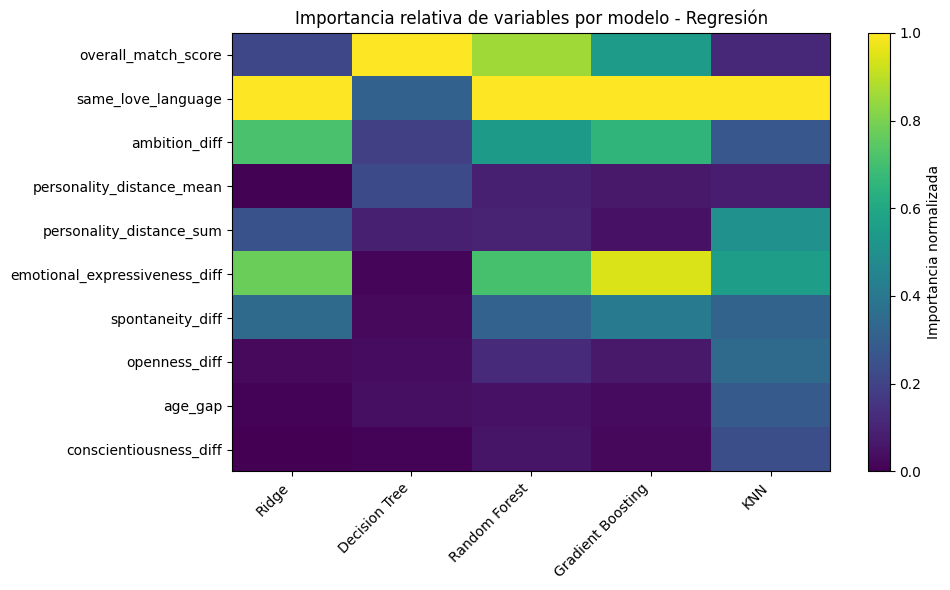

,Ridge,Decision Tree,Random Forest,Gradient Boosting,KNN
overall_match_score,0.001336,0.191743,0.005701,0.002771,0.000785
same_love_language,0.006194,0.059805,0.006661,0.005031,0.007192
ambition_diff,0.004419,0.036171,0.003634,0.003291,0.001939
personality_distance_mean,0.000025,0.043066,0.000588,0.000350,0.000559
personality_distance_sum,0.001555,0.016952,0.000631,0.000237,0.003625
emotional_expressiveness_diff,0.004799,0.003572,0.004714,0.004752,0.004005
spontaneity_diff,0.002137,0.004730,0.002100,0.002095,0.002299
openness_diff,0.000163,0.006562,0.000815,0.000351,0.002472
age_gap,0.000064,0.007550,0.000324,0.000139,0.002030
conscientiousness_diff,-0.000003,0.001444,0.000387,0.000101,0.001730


In [ ]:
# =========================
# 4.7 IMPORTANCIA DE VARIABLES - REGRESIÓN
# =========================

perm_importances_reg = {}

for name, model in regression_models.items():
    result = permutation_importance(
        model,
        X_val_reg_sel,
        y_val_reg,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_squared_error"
    )

    importances = pd.Series(result.importances_mean, index=selected_features_reg)
    perm_importances_reg[name] = importances

perm_importances_reg_df = pd.DataFrame(perm_importances_reg).fillna(0)

# Top variables en promedio
top_features_reg = perm_importances_reg_df.mean(axis=1).sort_values(ascending=False).head(10).index
perm_importances_reg_top = perm_importances_reg_df.loc[top_features_reg]

# Normalización por modelo
perm_importances_reg_norm = perm_importances_reg_top.copy()
for col in perm_importances_reg_norm.columns:
    max_val = perm_importances_reg_norm[col].abs().max()
    if max_val > 0:
        perm_importances_reg_norm[col] = perm_importances_reg_norm[col] / max_val

plt.figure(figsize=(10, 6))
plt.imshow(perm_importances_reg_norm, aspect="auto")
plt.colorbar(label="Importancia normalizada")
plt.xticks(ticks=np.arange(len(perm_importances_reg_norm.columns)), labels=perm_importances_reg_norm.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(perm_importances_reg_norm.index)), labels=perm_importances_reg_norm.index)
plt.title("Importancia relativa de variables por modelo - Regresión")
plt.tight_layout()
plt.show()

display(perm_importances_reg_top)

## 5. Conclusiones

### Sobre clasificación (`compatible`)

Tras comparar cinco modelos distintos sobre una partición 70/15/15, se ha seleccionado como mejor modelo aquel que obtiene el mejor equilibrio entre **F1-score** y **ROC-AUC** en el conjunto de validación, confirmando posteriormente su rendimiento en el conjunto de test.

El modelo con mejor comportamiento ha sido **Logistic Regression**, que obtuvo el mayor F1-score en validación y mantuvo un rendimiento estable en test. Este resultado indica que, tras el proceso de ingeniería de características, la relación entre las variables derivadas y la compatibilidad puede modelarse adecuadamente mediante una frontera relativamente simple e interpretable.

El análisis de las matrices de confusión en validación y test muestra un comportamiento consistente del modelo, con una distribución equilibrada entre verdaderos positivos y verdaderos negativos, y una diferencia moderada entre falsos positivos y falsos negativos. En particular, se observa una ligera tendencia a generar más falsos positivos, lo que sugiere que el modelo es algo permisivo a la hora de predecir compatibilidad.

Asimismo, la similitud entre los resultados obtenidos en validación y test indica una buena capacidad de generalización, lo que refuerza la validez del modelo seleccionado.

En conjunto, estos resultados sugieren que el problema de clasificación de compatibilidad puede abordarse de forma efectiva mediante modelos relativamente simples, siempre que se disponga de un adecuado proceso de ingeniería de características.

---

### Sobre regresión (`relationship_longevity_months`)

En el problema de regresión, el mejor modelo ha sido aquel que ha obtenido los menores valores de **MAE** y **RMSE** en validación, manteniendo un valor de **R²** lo más alto posible en test.

El modelo con mejor rendimiento ha sido **Ridge**, aunque con un valor de **R²** reducido, lo que indica que las variables disponibles explican solo una parte limitada de la variabilidad de la duración de la relación.

El análisis gráfico del modelo (comparación entre valores reales y predichos, así como la distribución de errores) revela un comportamiento característico de regresión hacia la media, donde las predicciones tienden a concentrarse en un rango reducido de valores sin capturar adecuadamente la variabilidad real de la variable objetivo.

Este comportamiento sugiere que la longevidad relacional es un fenómeno significativamente más complejo que la compatibilidad binaria, y que depende de factores adicionales no recogidos en el dataset, o de relaciones no lineales más difíciles de modelar con los enfoques utilizados.

---

### Conclusión global

Los resultados obtenidos ponen de manifiesto una diferencia clara entre ambos problemas: mientras que la **compatibilidad** puede modelarse de forma razonable a partir de variables estructuradas y relaciones entre perfiles, la **longevidad** presenta una mayor complejidad y menor capacidad explicativa con la información disponible.

Esto refuerza la idea de que no todos los problemas dentro de un mismo dominio presentan el mismo grado de dificultad, y destaca la importancia de analizar no solo el rendimiento de los modelos, sino también la naturaleza de la variable objetivo y la información disponible.

Como líneas futuras de trabajo, se plantea la posibilidad de incorporar nuevas variables, aplicar técnicas de optimización de hiperparámetros o utilizar modelos más complejos que permitan capturar relaciones no lineales más profundas, especialmente en la tarea de regresión.

## 6. Mejoras

A partir del análisis realizado en este hito, se identifican diversas líneas de mejora orientadas a incrementar el rendimiento y la robustez del sistema desarrollado:

- **Optimización de hiperparámetros**: realizar una búsqueda sistemática (Grid Search o Random Search) permitiría mejorar el rendimiento de los modelos, especialmente en aquellos más sensibles a su configuración, como Random Forest, Gradient Boosting o KNN.

- **Mejora del feature engineering**: dado que el rendimiento en clasificación ha sido notablemente superior al de regresión, resulta relevante profundizar en la construcción de variables derivadas más ricas que capturen mejor la relación entre individuos, incluyendo nuevas interacciones, medidas de similitud más complejas o transformaciones no lineales.

- **Incorporación de nuevas variables**: los resultados obtenidos en la predicción de longevidad sugieren que la información disponible no es suficiente para explicar completamente la variable objetivo. En este sentido, sería recomendable incluir nuevas variables relacionadas con factores emocionales, contextuales o temporales que puedan influir en la duración de una relación.

- **Uso de modelos más complejos**: explorar modelos más avanzados, como redes neuronales o técnicas de boosting más sofisticadas, podría permitir capturar relaciones no lineales más profundas, especialmente en la tarea de regresión.

- **Modelado conjunto de compatibilidad y longevidad**: en futuras iteraciones, podría abordarse el problema mediante modelos multi-output que permitan predecir simultáneamente ambas variables, aprovechando posibles dependencias entre ellas.

- **Técnicas avanzadas de explicabilidad**: la incorporación de métodos como SHAP o LIME permitiría analizar en mayor profundidad la contribución de cada variable en las predicciones, mejorando la interpretabilidad del sistema y facilitando su integración en entornos reales.
